# Advanced Performance

`PauliPropagation.jl` has a few extra gears for when a simulation's Pauli sum grows large: an array-backed Pauli sum, an in-place cache for repeated time evolution, threading, and a set of fused kernels that trade a little exactness for speed. This notebook walks through all of them using the same $6\times6$ tilted-field Ising circuit as `bench/example2.jl`, and along the way takes a closer look at how much work a single gate application actually costs, depending on where in the circuit it sits.

Everything here runs in well under a minute.

In [1]:
using PauliPropagation
using PauliPropagation.Performance
using Base.Threads
using Printf
using Plots

println("Threads.nthreads() = $(nthreads())")

Threads.nthreads() = 8


## A $6\times6$ tilted-field Ising circuit

This is the same setup as `bench/example2.jl`: a $6\times6$ grid of $36$ qubits on a `rectangletopology`, one Trotter `layer` of single-qubit $R_x$/$R_z$ rotations plus nearest-neighbour $R_{zz}$ rotations, and an observable $Z_{21}Z_{22}$ sitting right in the middle of the grid. We truncate away Pauli strings whose coefficient has decayed below $2^{-20}$ (`min_abs_coeff`), which keeps the backpropagated Pauli sum from growing without bound.

In [2]:
nx = 6
ny = 6
nq = nx * ny

dt = 0.05
h = 1.0
J = 0.5

topology = rectangletopology(nx, ny)
layer = PauliRotation[]
rxlayer!(layer, nq)
rzlayer!(layer, nq)
rzzlayer!(layer, topology)

thetas = ones(countparameters(layer)) * dt * 2

x_inds = getparameterindices(layer, PauliRotation, [:X])
z_inds = getparameterindices(layer, PauliRotation, [:Z])
zz_inds = getparameterindices(layer, PauliRotation, [:Z, :Z])
thetas[x_inds] .*= h
thetas[z_inds] .*= h
thetas[zz_inds] .*= J

pstr = PauliString(nq, [:Z, :Z], [21, 22])
min_abs_coeff = 2.0^(-20)

nlayers = 14
nothing

## Switching to `VectorPauliSum`

So far we've used the default `PauliSum`, which is backed by a `Dict`. It is flexible and generayll a robust choice. But once a Pauli sum grows into the hundreds of thousands of terms, as ours will below, dictionary lookups start to cost real time. `VectorPauliSum` is the array-backed alternative built for exactly that regime, and it's the backend that every other technique in this notebook builds on.

`VectorPauliSum` stores the same information as `PauliSum` -- a Pauli string and a coefficient per term -- just laid out differently. Instead of a hash map, it keeps two plain arrays, `terms` and `coeffs`, where `terms[i]` and `coeffs[i]` belong together. There's no hashing and no chasing pointers between buckets, just two contiguous blocks of memory that the apply/merge/truncate pipeline can sweep over directly. That's what makes it fast to iterate and straightforward to split across threads. The one thing you give up is cheap lookup by Pauli string -- finding a specific term's coefficient means scanning (or keeping the arrays sorted), rather than an $O(1)$ dictionary hit. For the bulk operations a Trotter step needs, that trade is well worth it, and at the sizes this notebook reaches it's already several times faster than the `Dict`-backed default.

## `PropagationCache` and in-place `propagate!`

Calling `propagate(circuit, psum, thetas)` returns a fresh Pauli sum every time, which is fine for a single shot. But a Trotterized time evolution applies the *same* layer many times in a row and usually wants the expectation value after every step -- allocating a brand new array-backed sum on every layer would waste a lot of time on memory allocation alone. `propagate!(layer, prop_cache, thetas; kwargs...)` avoids that by running one layer *in place*.

`PropagationCache(psum)` wraps a *main* and an *auxiliary* copy of your Pauli sum (for `VectorPauliSum`, it also carries a couple of scratch arrays used during the merge step). A `propagate!` call writes the result of applying a layer into the auxiliary buffer, then swaps main and auxiliary so the auxiliary becomes the new main -- nothing needs to be freshly allocated per layer. You can read off an observable's expectation value at any point without extracting a full Pauli sum: `overlapwithzero(prop_cache)` computes $\langle 0|\cdot|0\rangle$ straight from the cache.

Because `VectorPauliSum` is array-backed, growing its arrays on demand is itself expensive: Julia has to allocate a bigger array and copy every existing element into it, every time the current capacity is exceeded. `resize!(prop_cache, N)` sidesteps that by growing the main buffer, the auxiliary buffer, and the scratch arrays to length `N` once, up front, with `N` a generous over-estimate of how large the Pauli sum will get. As long as the sum never exceeds `N` terms, no `propagate!` call in the hot loop needs to touch the allocator again.

The cell below runs the same 10 layers four times over, each time with one more optimization switched on, and keeps the per-layer wall time of every run so we can plot them against each other:

1. the `Dict`-backed default `PauliSum`,
2. `VectorPauliSum` with `thread=false`,
3. `VectorPauliSum` with `thread=true`,
4. `PauliPropagation.Performance`'s fused kernels (both introduced properly below).

In [3]:
function run_dict(nlayers)
    cache = PropagationCache(PauliSum(pstr))
    times = Float64[]
    for l in 1:nlayers
        r = @timed propagate!(layer, cache, thetas; min_abs_coeff=min_abs_coeff)
        push!(times, r.time - r.compile_time)  # exclude one-time JIT compilation
    end
    return times, cache
end

function run_vector(nlayers; thread, fused, capacity=1_500_000)
    cache = PropagationCache(VectorPauliSum(pstr))
    resize!(cache, capacity)  # pre-allocate: avoids costly array growth mid-run
    propfunc = fused ? Performance.propagate! : PauliPropagation.propagate!

    if thread
        # The threaded backend compiles new specializations the first time the sum size
        # crosses certain thresholds, not only on the very first call. A full silent pass
        # over a throwaway copy is what keeps the timed loop below free of compilation blips.
        let warm = deepcopy(cache)
            for _ in 1:nlayers
                propfunc(layer, warm, thetas; min_abs_coeff=min_abs_coeff, thread=true)
            end
        end
    end

    times = Float64[]
    expectations = Float64[]
    for l in 1:nlayers
        if thread
            push!(times, @elapsed propfunc(layer, cache, thetas; min_abs_coeff=min_abs_coeff, thread=true))
        else
            r = @timed propfunc(layer, cache, thetas; min_abs_coeff=min_abs_coeff, thread=false)
            push!(times, r.time - r.compile_time)
        end
        push!(expectations, overlapwithzero(cache))
    end
    return times, expectations, cache
end

dict_times, _ = run_dict(nlayers)
serial_times, _, _ = run_vector(nlayers; thread=false, fused=false)
threaded_times, _, _ = run_vector(nlayers; thread=true, fused=false)
fused_times, expectations, prop_cache = run_vector(nlayers; thread=true, fused=true)

@printf("%-40s  last layer: %7.3fs   total: %6.3fs\n", "PauliSum (Dict)", dict_times[end], sum(dict_times))
@printf("%-40s  last layer: %7.3fs   total: %6.3fs\n", "VectorPauliSum, thread=false", serial_times[end], sum(serial_times))
@printf("%-40s  last layer: %7.3fs   total: %6.3fs\n", "VectorPauliSum, thread=true", threaded_times[end], sum(threaded_times))
@printf("%-40s  last layer: %7.3fs   total: %6.3fs\n", "Performance.propagate! (fused, threaded)", fused_times[end], sum(fused_times))
@printf("\nfinal Pauli sum: %d terms\n", length(prop_cache))

PauliSum (Dict)                           last layer:   4.144s   total:  9.236s
VectorPauliSum, thread=false              last layer:   1.264s   total:  2.936s
VectorPauliSum, thread=true               last layer:   0.976s   total:  2.545s
Performance.propagate! (fused, threaded)  last layer:   0.516s   total:  1.358s

final Pauli sum: 1179876 terms


`thread` controls whether `VectorPauliSum` spreads its apply/merge/truncate passes across multiple tasks (via `AcceleratedKernels`); `thread=true` is the default and uses up to `Threads.nthreads()` tasks, `thread=false` forces a single serial pass. Threading only pays off once a Pauli sum is large enough that the work per task dwarfs the overhead of spawning and synchronizing tasks -- `bench/example2.jl` pre-allocates for as many as 9,000,000 terms specifically to sit well inside that regime, so don't expect a dramatic gap yet at the modest sizes below. `thread=false` is also the right call when you're already inside your own `Threads.@threads` loop: it stops PauliPropagation.jl from spawning further nested tasks that would just fight yours for the same cores.

`PauliPropagation.Performance` is an opt-in module (`using PauliPropagation.Performance`) with alternative, fused implementations of the `VectorPauliSum` apply/merge/truncate pipeline. The stock `propagate!` runs apply, merge and truncate as separate passes over the data; `Performance.propagate!` fuses them into fewer passes over the same arrays, trading a small amount of exactness in intermediate ordering -- results can differ very slightly, e.g. in floating-point summation order -- for noticeably higher throughput. It shares its signature with the stock function plus a `fused::Bool=true` keyword, so `fused=false` falls back to byte-identical stock behaviour.

The plot below makes the four methods directly comparable: it's the wall time of that one specific layer, not a running total, on a log scale so the growing gap between methods stays visible across the whole range.

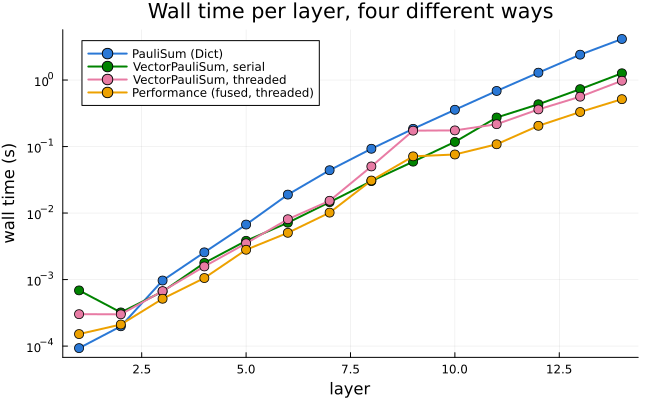

In [4]:
blue, green, magenta, yellow = "#2a78d6", "#008300", "#e87ba4", "#eda100"

p1 = plot(
    xlabel="layer", ylabel="wall time (s)", yscale=:log10,
    legend=:topleft, title="Wall time per layer, four different ways", size=(650, 400),
)
plot!(p1, 1:nlayers, dict_times, label="PauliSum (Dict)", color=blue, linewidth=2, marker=:circle, markersize=5)
plot!(p1, 1:nlayers, serial_times, label="VectorPauliSum, serial", color=green, linewidth=2, marker=:circle, markersize=5)
plot!(p1, 1:nlayers, threaded_times, label="VectorPauliSum, threaded", color=magenta, linewidth=2, marker=:circle, markersize=5)
plot!(p1, 1:nlayers, fused_times, label="Performance (fused, threaded)", color=yellow, linewidth=2, marker=:circle, markersize=5)
p1

The fused/threaded run above also handed us the expectation value $\langle Z_{21} Z_{22}\rangle$ after every layer, read straight off the cache with `overlapwithzero` -- no extra propagation needed:

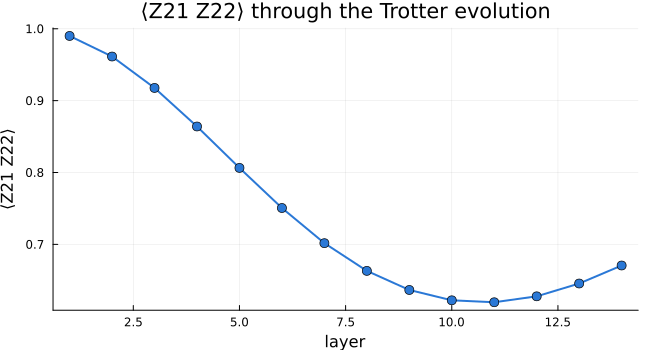

In [5]:
plot(1:nlayers, expectations, xlabel="layer", ylabel="⟨Z21 Z22⟩", legend=false,
    title="⟨Z21 Z22⟩ through the Trotter evolution", color=blue, linewidth=2, marker=:circle, markersize=5, size=(650, 350))

## A gate on the edge vs. a gate in the middle

`prop_cache` (from the fused/threaded run above) now holds a real Pauli sum after 10 actual Trotter layers of this circuit -- not something synthetic or randomly generated. Let's take a snapshot of it and time a single gate application at two different sites: the $R_{zz}$ rotation at a corner of the $6\times6$ grid (qubit 1, with only 2 neighbours -- "on the edge") versus the $R_{zz}$ rotation right at the centre (qubits 21/22, with 4 neighbours each, exactly where our observable lives -- "in the middle").

A `PauliRotation` only branches -- duplicates into two terms -- the Pauli strings that anticommute with its generator; anything that commutes just passes through untouched. Deep in the bulk, several layers of light-cone spreading have given the operator heavy overlap with the observable's own neighbourhood, so a much larger fraction of terms anticommute with a bulk $ZZ$ generator than at a boundary site. The middle gate ends up doing more branching and merging work for the same input size, even though the per-term dispatch cost is identical.

To keep the timing honest, both gates run *in place* on their own pre-allocated `VectorPropagationCache` (built with `resize!`, just like above); copying the snapshot into each cache happens before the `@elapsed` call, not inside it.

In [6]:
snapshot = VectorPauliSum(prop_cache)  # a real, physical mid-circuit Pauli sum
n = length(snapshot)

edge_pos = findfirst(==((1, 2)), topology)
mid_pos = findfirst(==((21, 22)), topology)
edge_gate, edge_theta = layer[zz_inds[edge_pos]], thetas[zz_inds[edge_pos]]
mid_gate, mid_theta = layer[zz_inds[mid_pos]], thetas[zz_inds[mid_pos]]

capacity = 2n
edge_cache = PropagationCache(deepcopy(snapshot))
resize!(edge_cache, capacity)
mid_cache = PropagationCache(deepcopy(snapshot))
resize!(mid_cache, capacity)

# warm up on throwaway copies, so the real (pre-allocated) caches stay untouched
Performance.propagate!(edge_gate, deepcopy(edge_cache), edge_theta; min_abs_coeff=min_abs_coeff, thread=false)
Performance.propagate!(mid_gate, deepcopy(mid_cache), mid_theta; min_abs_coeff=min_abs_coeff, thread=false)

# the only timed operation is a single in-place propagate! on a pre-allocated cache
t_edge = @elapsed Performance.propagate!(edge_gate, edge_cache, edge_theta; min_abs_coeff=min_abs_coeff, thread=false)
t_mid = @elapsed Performance.propagate!(mid_gate, mid_cache, mid_theta; min_abs_coeff=min_abs_coeff, thread=false)

mpaulis_edge = n / t_edge / 1e6
mpaulis_mid = n / t_mid / 1e6
@printf("snapshot: %d Pauli terms\n", n)
@printf("edge gate   on qubits %s: %7.2f Mpaulis/s  (%d -> %d terms)\n", edge_gate.qinds, mpaulis_edge, n, length(edge_cache))
@printf("middle gate on qubits %s: %7.2f Mpaulis/s  (%d -> %d terms)\n", mid_gate.qinds, mpaulis_mid, n, length(mid_cache))

snapshot: 1179876 Pauli terms
edge gate   on qubits [1, 2]:  370.68 Mpaulis/s  (1179876 -> 1179876 terms)
middle gate on qubits [21, 22]:   80.23 Mpaulis/s  (1179876 -> 1190480 terms)


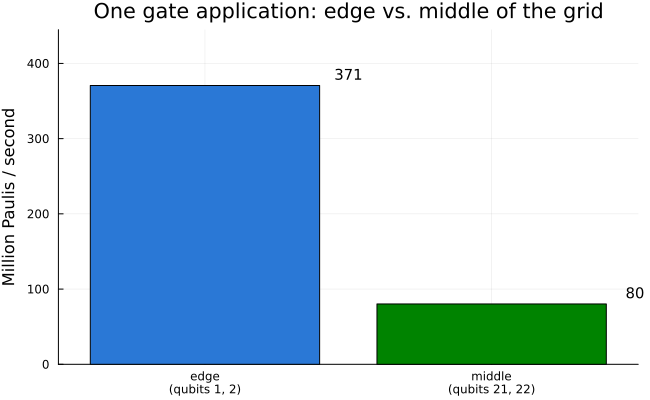

In [7]:
ymax = max(mpaulis_edge, mpaulis_mid)
p3 = bar(["edge\n(qubits 1, 2)", "middle\n(qubits 21, 22)"], [mpaulis_edge, mpaulis_mid],
    color=[blue, green], legend=false, ylabel="Million Paulis / second", ylims=(0, 1.2 * ymax),
    title="One gate application: edge vs. middle of the grid", size=(650, 400))
annotate!(p3, 1, mpaulis_edge + 0.04 * ymax, text(@sprintf("%.0f", mpaulis_edge), 10))
annotate!(p3, 2, mpaulis_mid + 0.04 * ymax, text(@sprintf("%.0f", mpaulis_mid), 10))
p3

## Wrapping up

Reach for `VectorPauliSum` once a simulation's Pauli sum grows into the hundreds of thousands of terms or more, and wrap it in a `PropagationCache` so that time evolution can run through in-place `propagate!` calls -- read off `overlapwithzero(prop_cache)` (or another overlap function) after each layer rather than extracting a full sum. Just remember to call `resize!(prop_cache, N)` up front with a generous size estimate; that's what makes the in-place calls above allocation-free.

From there, it's worth benchmarking `thread=false` against `thread=true` for your own problem size, and disabling threading explicitly if you're already parallelizing at a higher level. If you need the very last bit of throughput and can tolerate tiny floating-point-order differences, `PauliPropagation.Performance`'s fused `propagate!`/`propagate` are there for that.

And finally: not all gates cost the same. A gate deep in an operator's support does more branching and merging work than one sitting at the edge of its light cone, even for identical input size.